# 

In [ ]:
# BERTopic と併用するために必要な NLP / ML パッケージ
!pip install "numpy<2.0.0,>=1.26.0"
!pip install pandas
!pip install scikit-learn
!pip install hdbscan
!pip install umap-learn
!pip install sentence-transformers
!pip install tqdm

In [ ]:
 **BERTopic 実行時の `UnicodeEncodeError`（latin-1）** トラブルは、Python のバージョンではなく **Hugging Face への通信で使われる HTTP ヘッダーに “latin-1 で表現できない文字” が混ざった**のが原因でした。解決までの要点をまとめます。
---
## 症状

* `topic_model.fit_transform(docs)` の途中（埋め込みモデル取得）で落ちる

* スタックトレース末尾がだいたいこうなる：

  * `http.client.py putheader`
  * `UnicodeEncodeError: 'latin-1' codec can't encode characters ...`

* 直前に `SentenceTransformer` が Hugging Face からモデルを落とそうとしているログが出る
  例：`paraphrase-multilingual-MiniLM-L12-v2`

---

## 原因（今回の確定原因）

* 環境変数の中に **latin-1 にできない値**があり、それが **HTTPヘッダーとして送られた**
* 今回は診断コードで特定できて、犯人は **`HF_TOKEN`** だった

### 何が起きていたか

* `HF_TOKEN` は `huggingface_hub` が **Authorization ヘッダー**に使う
* HTTPヘッダーは内部的に latin-1 前提で扱われる箇所があり
* `HF_TOKEN` の値に **日本語・全角・不可視文字（全角スペース、改行など）**が混ざっていて `putheader()` が失敗した

---

## 切り分け方法（今回有効だった手順）

### 1) 非latin-1の環境変数を検出

```python
import os
bad = []
for k, v in os.environ.items():
    try:
        v.encode("latin-1")
    except Exception:
        bad.append(k)
print("Non-latin1 env vars:", bad)
```

* 結果：`['HF_TOKEN']` が出た → 原因確定

### 2) 一時回避（Notebook内で無効化）

```python
import os
os.environ.pop("HF_TOKEN", None)
```

* ただし **カーネル再起動**が重要（既にロードされた設定を切るため）

---

## 恒久対策（最も重要）

### Windows の環境変数から `HF_TOKEN` を削除

* 設定 → システム → バージョン情報 → システムの詳細設定 → 環境変数
* 「ユーザー環境変数」「システム環境変数」両方で `HF_TOKEN` があれば削除
* その後 **PC再起動**

→ 再起動後も BERTopic が正常動作したので、恒久的に解決。

---

## なぜ「Python 3.11に戻しても直らなかった」のか

* 問題は Python のエンコーディングやバージョン互換ではなく、
* **外部通信（Hugging Face）で送るヘッダー値の不正文字**だったため
  → Python 3.11でも同じ条件なら同じエラーになります。

---

## 再発防止のベストプラクティス

* `HF_TOKEN` を環境変数に直接ベタ書きで入れない（コピペで変な文字が混ざりやすい）
* どうしても認証が必要なら、**CLIでログイン**する（安全）

  * `huggingface-cli login`
* 問題が再発したら、まず上の「Non-latin1 env vars」チェックを実行すると早い

---

## 今回の解決の結論

* **`HF_TOKEN` が非latin-1文字を含んでいたことが原因**
* `HF_TOKEN` を削除（Notebook内＋Windows環境変数）して再起動
* 以後、BERTopic が正常動作するようになった

必要なら、「HF_TOKEN がどこで設定されたのか（誰が/いつ/何のツールが）」を追跡する手順（PowerShell プロファイル、.env、VS Code 設定など）もまとめられます。


In [ ]:
# 推奨インストール順序（Python 3.12.9 直入れ）
# python -m pip install -U pip setuptools wheel


In [ ]:
# ② 最重要：PyTorch（最初に・単独で）
# pip install torch --index-url https://download.pytorch.org/whl/cpu


In [ ]:
#③ 数値計算・クラスタリング系（BERTopicの土台）
# pip install -U numpy pandas scikit-learn umap-learn hdbscan


In [ ]:
# 日本語処理（GiNZA 等）を使う場合
# pip install -U "spacy>=3.7,<3.8" ja-ginza janome sudachipy sudachidict_core
# python -m spacy download ja_ginza


In [ ]:
# pip install -U sentence-transformers transformers huggingface_hub accelerate bertopic
# python -c "from bertopic import BERTopic; print('BERTopic OK')"


In [1]:
# pythonのバージョンやインストールされているパスを確認する。
import sys
print(sys.executable)
print(sys.version)


C:\Users\mzjin\AppData\Local\Programs\Python\Python312\python.exe
3.12.9 (tags/v3.12.9:fdb8142, Feb  4 2025, 15:27:58) [MSC v.1942 64 bit (AMD64)]


In [2]:
# sentence_transformersが読み込まれているか確認する。
from sentence_transformers import SentenceTransformer

m = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
print("loaded")


C:\Users\mzjin\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
C:\Users\mzjin\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\utils\hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


loaded


In [3]:
# トピック分析が作動しているか簡易テストを行う
from bertopic import BERTopic
import umap
from hdbscan import HDBSCAN

docs = [
    "Windows 11で隠しフォルダを表示する方法を知りたい",
    "PowerShellの実行ポリシーでactivateがブロックされた",
    "PythonでBERTopicを使ってトピック分析を試したい",
    "Jupyter Notebookの.ipynb_checkpointsとは何か",
    "機械学習で文章をクラスタリングして話題を分ける",
    "BERTopicは文章をトピックに分けて要約できる",
]

umap_model = umap.UMAP(
    n_neighbors=2,
    n_components=2,
    init="random",
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=2,
    min_samples=1,          # ← 小さく
    prediction_data=False   # ← これで今回のエラー回避
)

topic_model = BERTopic(
    language="multilingual",
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs)

print(topic_model.get_topic_info())
for d, t in zip(docs, topics):
    print(f"[topic {t}] {d}")


2026-01-21 16:30:07,579 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-01-21 16:30:12,315 - BERTopic - Embedding - Completed ✓
2026-01-21 16:30:12,317 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-21 16:30:19,923 - BERTopic - Dimensionality - Completed ✓
2026-01-21 16:30:19,924 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-21 16:30:19,930 - BERTopic - Cluster - Completed ✓
2026-01-21 16:30:19,932 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-21 16:30:19,942 - BERTopic - Representation - Completed ✓


   Topic  Count                                               Name  \
0     -1      2  -1_11で隠しフォルダを表示する方法を知りたい_windows_pythonでbertop...   
1      0      2  0_jupyter_ipynb_checkpointsとは何か_powershellの実行ポ...   
2      1      2  1_bertopicは文章をトピックに分けて要約できる_機械学習で文章をクラスタリングして話...   

                                      Representation  \
0  [11で隠しフォルダを表示する方法を知りたい, windows, pythonでbertop...   
1  [jupyter, ipynb_checkpointsとは何か, powershellの実行...   
2  [bertopicは文章をトピックに分けて要約できる, 機械学習で文章をクラスタリングして話...   

                                 Representative_Docs  
0  [PythonでBERTopicを使ってトピック分析を試したい, Windows 11で隠し...  
1  [PowerShellの実行ポリシーでactivateがブロックされた, Jupyter N...  
2  [BERTopicは文章をトピックに分けて要約できる, 機械学習で文章をクラスタリングして話...  
[topic -1] Windows 11で隠しフォルダを表示する方法を知りたい
[topic 0] PowerShellの実行ポリシーでactivateがブロックされた
[topic -1] PythonでBERTopicを使ってトピック分析を試したい
[topic 0] Jupyter Notebookの.ipynb_checkpointsとは何か
[topic 1] 機械学習で文章をクラスタリングして話題を分ける
[topic 1] BERTopicは文章をトピックに分けて要約できる


In [1]:
# pip install -U requests plotly pandas

In [4]:
# テキストを読み込みのテストを行う
import requests

#　テキストがおかれているパスとファイル名前
url = "https://raw.githubusercontent.com/mining-jin/data-/main/sakubun259/akke2.txt"
r = requests.get(url)
r.raise_for_status()
raw = r.content

for enc in ["cp932", "shift_jis", "utf-8"]:
    try:
        text = raw.decode(enc)
        break
    except UnicodeDecodeError:
        continue

print(text[:200]) 

私にとって、これから生きていくうえで、無くてはならない物を５つ上げるとしたら、その中に、ちょっと寒いけど、友達が入ると思う。
友達って、やはり多い方がいいと思う。
その時期、その時期によって友達は変わるものだ。
例えば、高校の友達、大学の友達、バイトの友達等で、環境が変われば、自分を取り囲んでくれる人も変わるから、友達が変わるのは、あたり前だと思う。
そうすると、友達たくさんいるのかな？
、と思う


In [5]:
# 指定したgithubのフォルダの中の全てのファイルを読み込んでトピック分析を行う。

import requests
import pandas as pd

from bertopic import BERTopic
import umap
from hdbscan import HDBSCAN

# ============================================================
# 設定（あなたの“動いている単一ファイルURL”に合わせて確定）
# ============================================================
# 実パスは "https://raw.githubusercontent.com/mining-jin/data-/main/sakubun259/である

GITHUB_REPO = "mining-jin/data-"     # ★ここが重要（data-sakubun259 ではない）
FOLDER_PATH = "sakubun259"          # ★ここも重要
TEXT_EXT = ".txt"
MIN_CHARS = 20

OUT_DOCS_CSV = "docs_with_topics.csv"
OUT_TOPICINFO_CSV = "topic_info.csv"
OUT_TOPICS_HTML = "bertopic_topics.html"

# ============================================================
# GitHub API でフォルダ内ファイル一覧を取得（contents API）
# ============================================================
session = requests.Session()
session.headers.update({"Accept": "application/vnd.github+json"})

api_url = f"https://api.github.com/repos/{GITHUB_REPO}/contents/{FOLDER_PATH}"
resp = session.get(api_url, timeout=60)
if resp.status_code != 200:
    print("Status:", resp.status_code)
    print("URL   :", api_url)
    try:
        print("Body  :", resp.json())
    except Exception:
        print("Body  :", resp.text[:500])
    resp.raise_for_status()

items = resp.json()

files = [
    {"name": it["name"], "path": it["path"], "url": it["download_url"]}
    for it in items
    if it.get("type") == "file"
    and it.get("name", "").lower().endswith(TEXT_EXT)
    and it.get("download_url")
]
files.sort(key=lambda x: x["name"])

print(f"Found txt files: {len(files)}")
if len(files) == 0:
    raise RuntimeError("このフォルダに .txt が見つかりませんでした。")

# ============================================================
# テキスト取得（あなたの単一ファイル読み込みと同じ方式）
# ============================================================
def fetch_text(url: str) -> str:
    r = session.get(url, timeout=60)
    r.raise_for_status()
    raw = r.content
    for enc in ["cp932", "shift_jis", "utf-8", "utf-8-sig"]:
        try:
            return raw.decode(enc)
        except UnicodeDecodeError:
            continue
    return raw.decode("utf-8", errors="replace")

docs, paths = [], []
for f in files:
    text = fetch_text(f["url"]).strip()
    if MIN_CHARS and len(text) < MIN_CHARS:
        continue
    docs.append(text)
    paths.append(f["path"])

print(f"Loaded docs: {len(docs)}")
if len(docs) == 0:
    raise RuntimeError("読み込めた文書が0件です（MIN_CHARS を下げてください）。")

# ============================================================
# BERTopic（安定設定）
# ============================================================
umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    init="random",
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=10,   # 細かすぎる→大きく、粗すぎる/ノイズ多い→小さく
    min_samples=1,
    prediction_data=False
)

topic_model = BERTopic(
    language="multilingual",
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    top_n_words=30,   # ← ここが重要
    verbose=True
)

topics, probs = topic_model.fit_transform(docs)

# ============================================================
# 保存（CSV + 図示HTML）
# ============================================================
df = pd.DataFrame({"path": paths, "topic": topics, "text": docs})
df.to_csv(OUT_DOCS_CSV, index=False, encoding="utf-8-sig")

topic_info = topic_model.get_topic_info()
topic_info.to_csv(OUT_TOPICINFO_CSV, index=False, encoding="utf-8-sig")

fig = topic_model.visualize_topics()
fig.write_html(OUT_TOPICS_HTML)

print("Saved:")
print(" -", OUT_DOCS_CSV)
print(" -", OUT_TOPICINFO_CSV)
print(" -", OUT_TOPICS_HTML)

topic_info.head(20)


Found txt files: 33


2026-01-21 16:31:09,804 - BERTopic - Embedding - Transforming documents to embeddings.


Loaded docs: 33


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

2026-01-21 16:31:14,786 - BERTopic - Embedding - Completed ✓
2026-01-21 16:31:14,786 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-21 16:31:14,835 - BERTopic - Dimensionality - Completed ✓
2026-01-21 16:31:14,835 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-21 16:31:14,837 - BERTopic - Cluster - Completed ✓
2026-01-21 16:31:14,837 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-21 16:31:14,856 - BERTopic - Representation - Completed ✓


Saved:
 - docs_with_topics.csv
 - topic_info.csv
 - bertopic_topics.html


,Topic,Count,Name,Representation,Representative_Docs
0,0,13,0_しかし_それは_でも_リカは,"[しかし, それは, でも, リカは, そして, この, どこの国の物でも, ではないだろう...",[そう書かれた母の日用のカードを見つけた。\n４月も終わりに近づいた頃だった。\nリカは、ど...
1,1,10,1_でも_だから_と思う_また,"[でも, だから, と思う, また, 私は, まず, ただ, リカは, そして, わたしは今...",[もっとたくさん友だちが欲しいと、携帯電話を片手に笑う女子高生たちをよく見かける。\n触れ合...
2,2,10,2_しかし_車は_だから_そして,"[しかし, 車は, だから, そして, 電車, トモキは, それから, それは, でも, お...",[正に、盛夏以外の何物でもなかった。\n度を過ぎた暑さと油の匂いの中、トモキの意識は遠くへ行...


In [ ]:
!pip -q install -U plotly kaleido pandas


[OK] update_topics で top_n_words=20 を反映しました
[Saved] topic_info.csv, docs_with_topics.csv
[Saved] 01_topics.html, 02_barchart.html, 03_heatmap.html, 04_hierarchy.html, 05_documents.html
[Saved] 06_document_dendrogram.html

All saved outputs:
 - topic_info.csv
 - docs_with_topics.csv
 - 01_topics.html
 - 02_barchart.html (n_words=20)
 - 03_heatmap.html
 - 04_hierarchy.html
 - 05_documents.html
 - 06_document_dendrogram.html


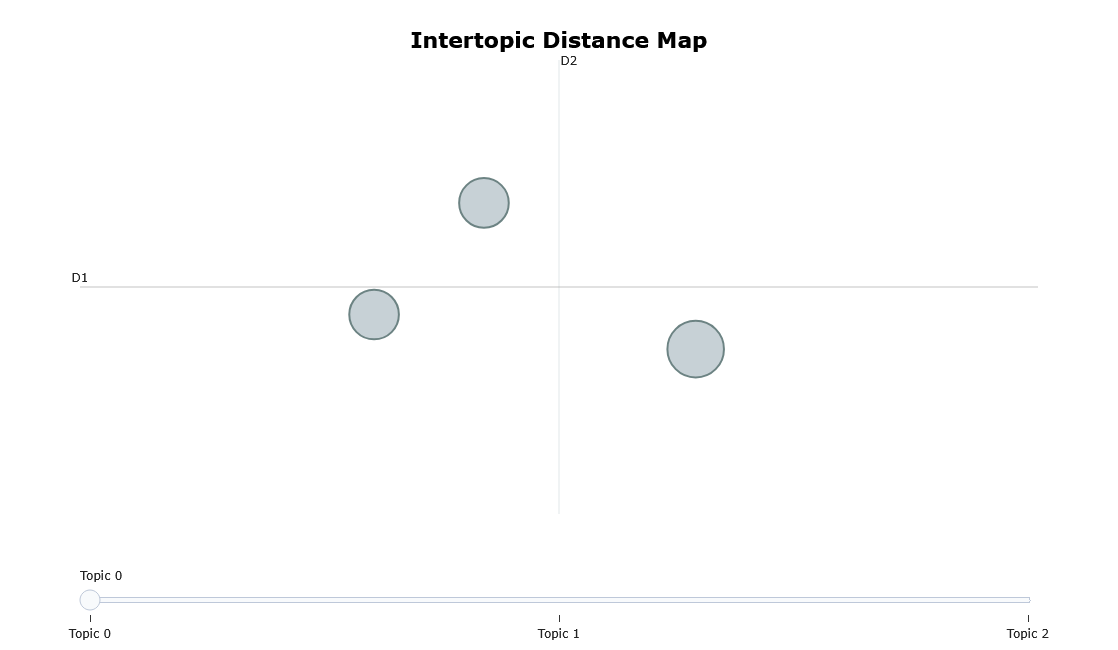

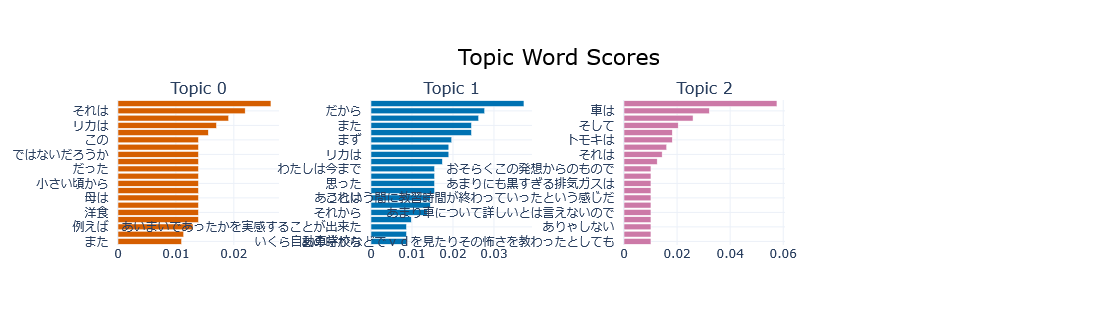

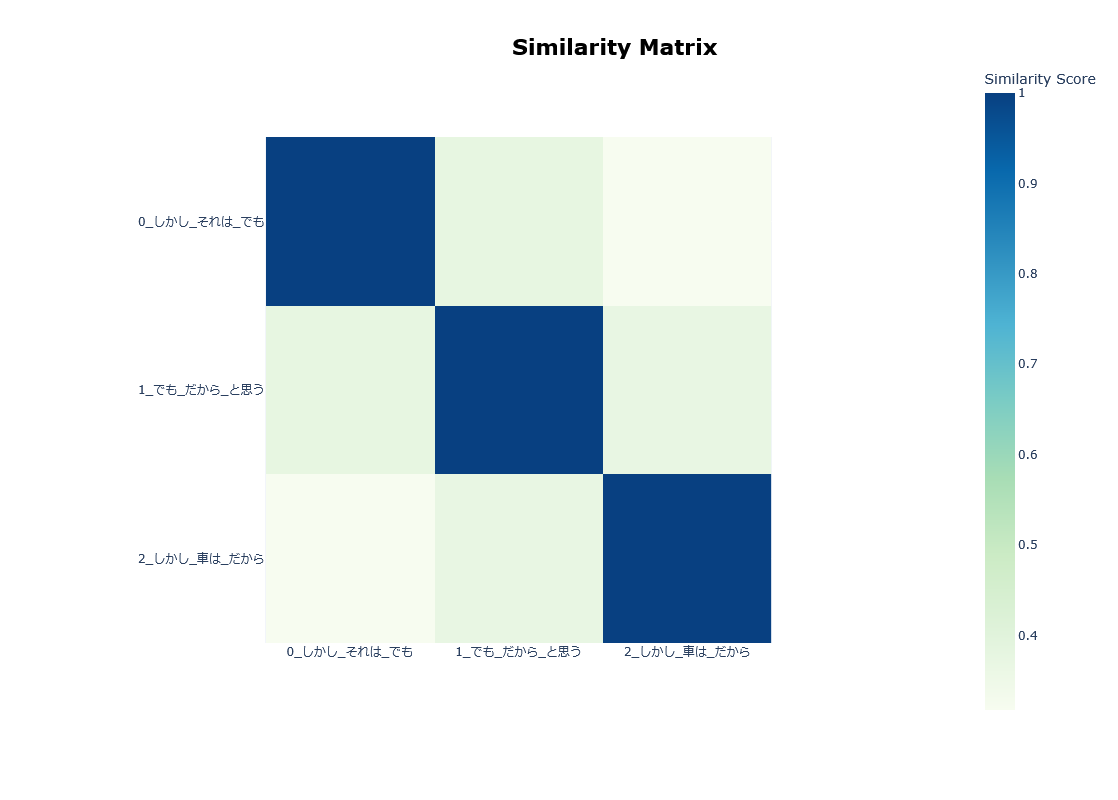

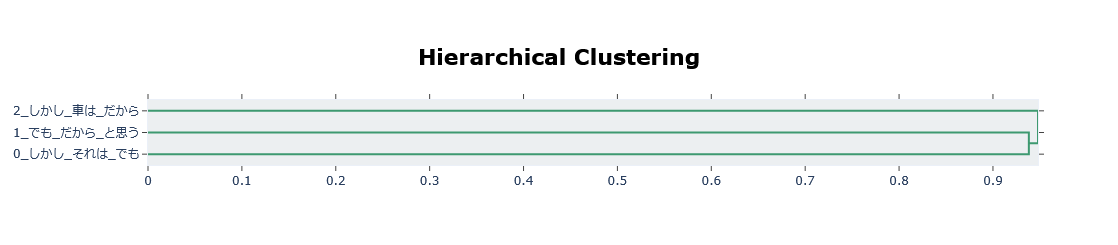

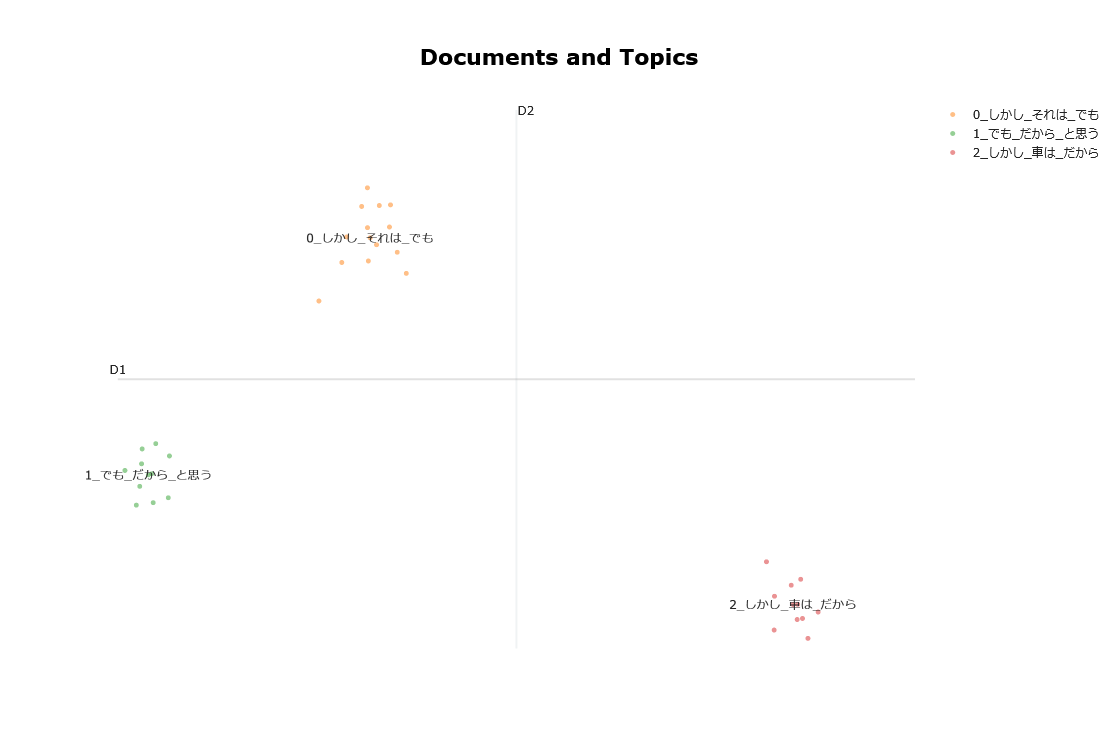

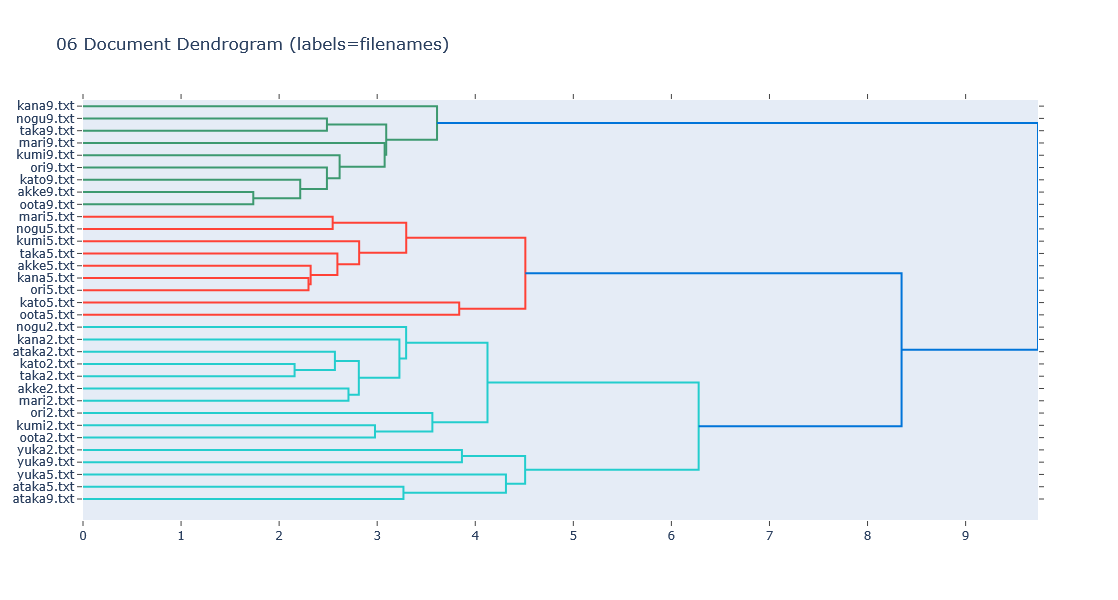

In [6]:
# ============================================================
# BERTopic 可視化・保存（CSV/HTML）＋ 文書樹形図（HTML）＋ Notebook display 専用セル
# ============================================================
# 前提：このセルを実行する前に、すでに以下が作られていること
#   - topic_model : 学習済みBERTopicモデル
#   - docs        : 文書リスト（list[str]）
#   - topics      : 各文書のトピック割当（list[int]）
#   - paths       : 各文書のラベル（GitHub上のパス等）（list[str]）
#
# 目的：
#  - top_n_words=20 をモデル側に反映（可能なら update_topics、無理なら再学習）
#  - CSV保存：topic_info.csv / docs_with_topics.csv
#  - HTML保存：topics/barchart/heatmap/hierarchy/documents + 文書樹形図(dendrogram)
#  - display は「別途」：最後に display 専用ブロックも用意（必要な人だけ実行）
#
# 必要（未インストールなら）:
#   pip install -U scipy plotly nbformat ipython
#   ※ display しないなら nbformat/ipython は不要（HTML保存だけならOK）
# ============================================================

import pandas as pd
from pathlib import Path
import numpy as np

# 樹形図（dendrogram）用
import plotly.figure_factory as ff
from scipy.cluster.hierarchy import linkage

# ============================================================
# 出力先
# ============================================================
out_dir = Path(".")
out_dir.mkdir(exist_ok=True)

# ============================================================
# 0) top_n_words=20 を反映（可能なら update_topics、無理なら再学習）
# ============================================================
TARGET_TOP_N_WORDS = 20

def reflect_top_n_words(topic_model, docs, top_n_words: int):
    """
    既存topic_modelに top_n_words を反映する。
    - 可能なら update_topics(docs, top_n_words=...) を使用
    - バージョン差分等で失敗したら例外を投げる
    """
    topic_model.update_topics(docs, top_n_words=top_n_words)
    return topic_model

updated = False
try:
    topic_model = reflect_top_n_words(topic_model, docs, TARGET_TOP_N_WORDS)
    updated = True
    print(f"[OK] update_topics で top_n_words={TARGET_TOP_N_WORDS} を反映しました")
except Exception as e:
    print("[INFO] update_topics で top_n_words を反映できませんでした。再学習に切り替えます。")
    print("  reason:", repr(e))

    # 再学習するための umap_model / hdbscan_model が無ければ最低限の安定設定で用意
    try:
        umap_model
    except NameError:
        import umap
        umap_model = umap.UMAP(n_neighbors=15, n_components=2, init="random", random_state=42)

    try:
        hdbscan_model
    except NameError:
        from hdbscan import HDBSCAN
        hdbscan_model = HDBSCAN(min_cluster_size=10, min_samples=1, prediction_data=False)

    from bertopic import BERTopic
    topic_model = BERTopic(
        language="multilingual",
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        top_n_words=TARGET_TOP_N_WORDS,
        verbose=True
    )
    topics, probs = topic_model.fit_transform(docs)
    updated = True
    print(f"[OK] 再学習で top_n_words={TARGET_TOP_N_WORDS} を反映しました")

if not updated:
    raise RuntimeError("top_n_words の反映に失敗しました。")

# ============================================================
# 1) topic_info / docs_with_topics を保存（CSV）
# ============================================================
topic_info = topic_model.get_topic_info()
topic_info.to_csv(out_dir / "topic_info.csv", index=False, encoding="utf-8-sig")

df_docs = pd.DataFrame({
    "path": paths,     # GitHub上のパス（ラベル）
    "topic": topics,
    "text": docs
})
df_docs.to_csv(out_dir / "docs_with_topics.csv", index=False, encoding="utf-8-sig")

print("[Saved] topic_info.csv, docs_with_topics.csv")

# ============================================================
# 2) 図示（HTML保存のみ：nbformat不要）
# ============================================================
topic_model.visualize_topics().write_html(out_dir / "01_topics.html")
topic_model.visualize_barchart(top_n_topics=30, n_words=20).write_html(out_dir / "02_barchart.html")
topic_model.visualize_heatmap().write_html(out_dir / "03_heatmap.html")
topic_model.visualize_hierarchy().write_html(out_dir / "04_hierarchy.html")
topic_model.visualize_documents(docs, sample=min(1000, len(docs))).write_html(out_dir / "05_documents.html")

print("[Saved] 01_topics.html, 02_barchart.html, 03_heatmap.html, 04_hierarchy.html, 05_documents.html")

# ============================================================
# 3) 追加：ドキュメントの樹形図（ラベル=paths）→ HTML保存
# ============================================================
# ラベル：長い場合はファイル名だけに短縮（フルpathsで良ければ短縮処理を外してください）
labels = [str(p).split("/")[-1].split("\\")[-1] for p in paths]

# 文書 embedding（fit_transform時に渡していなければここで作る）
embeddings = np.array(topic_model.embedding_model.embed(docs))

# 階層クラスタ（Ward法）
Z = linkage(embeddings, method="ward")

fig_dendro = ff.create_dendrogram(
    embeddings,
    linkagefun=lambda x: Z,
    labels=labels,
    orientation="left"
)

fig_dendro.update_layout(
    width=900,
    height=max(600, 18 * len(labels)),
    title="06 Document Dendrogram (labels=filenames)"
)

fig_dendro.write_html(out_dir / "06_document_dendrogram.html")
print("[Saved] 06_document_dendrogram.html")

print("\nAll saved outputs:")
print(" - topic_info.csv")
print(" - docs_with_topics.csv")
print(" - 01_topics.html")
print(" - 02_barchart.html (n_words=20)")
print(" - 03_heatmap.html")
print(" - 04_hierarchy.html")
print(" - 05_documents.html")
print(" - 06_document_dendrogram.html")

# ============================================================
# 4) Notebook内で display したい人向け（任意）
#    nbformat/ipython が無いとエラーになるので、必要な場合だけ実行してください。
# ============================================================

from IPython.display import display

display(topic_model.visualize_topics())
display(topic_model.visualize_barchart(top_n_topics=30, n_words=20))
display(topic_model.visualize_heatmap())
display(topic_model.visualize_hierarchy())
display(topic_model.visualize_documents(docs, sample=min(1000, len(docs))))
display(fig_dendro)


In [ ]:
### 形態素解析を行い付属語を取り除いた後のトピック分析。

In [ ]:
import sys
print(sys.executable)


In [3]:
# ============================================================
# 形態素解析を行い付属語を取り除いた後のトピック分析。
# ============================================================
# GitHub API でフォルダ内ファイル一覧を取得
# GiNZA（長い単位）で形態素解析 → 内容語だけ抽出（動詞を除外）
# 埋め込みモデル（明示）
# 結果を保存する
# ============================================================

import requests
import pandas as pd

import umap
from hdbscan import HDBSCAN
from bertopic import BERTopic

import spacy                                                 #形態素解析Ja-Ginza関連
from sklearn.feature_extraction.text import CountVectorizer  #特徴量処理関連
from sentence_transformers import SentenceTransformer


# ============================================================
# 設定
# ============================================================
GITHUB_REPO = "mining-jin/data-"   # あなたのrepoに合わせる
FOLDER_PATH = "sakubun259"
TEXT_EXT = ".txt"

MIN_CHARS = 20
MIN_TOKENS = 3

OUT_DOCS_CSV = "docs_with_topics.csv"
OUT_TOPICINFO_CSV = "topic_info.csv"
OUT_TOPICS_HTML = "bertopic_topics.html"

# ============================================================
# GitHub API でフォルダ内ファイル一覧を取得
# ============================================================
session = requests.Session()
session.headers.update({"Accept": "application/vnd.github+json"})

api_url = f"https://api.github.com/repos/{GITHUB_REPO}/contents/{FOLDER_PATH}"
resp = session.get(api_url, timeout=60)
if resp.status_code != 200:
    print("Status:", resp.status_code)
    print("URL   :", api_url)
    try:
        print("Body  :", resp.json())
    except Exception:
        print("Body  :", resp.text[:500])
    resp.raise_for_status()

items = resp.json()

files = [
    {"name": it["name"], "path": it["path"], "url": it["download_url"]}
    for it in items
    if it.get("type") == "file"
    and it.get("name", "").lower().endswith(TEXT_EXT)
    and it.get("download_url")
]
files.sort(key=lambda x: x["name"])

print(f"Found txt files: {len(files)}")
if len(files) == 0:
    raise RuntimeError("このフォルダに .txt が見つかりませんでした。")

# ============================================================
# テキスト取得
# ============================================================
def fetch_text(url: str) -> str:
    r = session.get(url, timeout=60)
    r.raise_for_status()
    raw = r.content
    for enc in ["cp932", "shift_jis", "utf-8", "utf-8-sig"]:
        try:
            return raw.decode(enc)
        except UnicodeDecodeError:
            continue
    return raw.decode("utf-8", errors="replace")

docs, paths = [], []
for f in files:
    text = fetch_text(f["url"]).strip()
    if MIN_CHARS and len(text) < MIN_CHARS:
        continue
    docs.append(text)
    paths.append(f["path"])

print(f"Loaded docs: {len(docs)}")
if len(docs) == 0:
    raise RuntimeError("読み込めた文書が0件です（MIN_CHARS を下げてください）。")

# ============================================================
# GiNZA（長い単位）で形態素解析 → 内容語だけ抽出（動詞を除外）
# ============================================================
nlp = spacy.load("ja_ginza", disable=["ner"])

try:
    import ginza
    ginza.set_split_mode(nlp, "C")  # 長い単位
    print("GiNZA split mode: C (long)")
except Exception as e:
    print("Warning: ginza.set_split_mode が使えませんでした。split mode は既定のままです。")
    print("  detail:", e)

# ★動詞 VERB を外す
CONTENT_POS = {"NOUN", "PROPN", "ADJ", "ADV"}

# 形容詞/副詞は lemma が効くことが多い。名詞は表層のままでも良いが、ここは一律lemmaに寄せる
CUSTOM_STOP = set()  # 動詞を外したなら「する/ある/いる」等は不要なので空でOK

def to_content_words(text: str) -> str:
    doc = nlp(text)
    toks = []
    for t in doc:
        if t.is_space or t.is_punct:
            continue
        if t.pos_ not in CONTENT_POS:
            continue

        token = t.lemma_ if t.lemma_ else t.text

        # spaCy stopwords は日本語では強く効かないこともあるので、必要なら使う
        if t.is_stop:
            continue
        if token in CUSTOM_STOP:
            continue

        token = token.strip()
        if not token:
            continue
        toks.append(token)

    return " ".join(toks)

docs_tokens = [to_content_words(d) for d in docs]

filtered_raw, filtered_docs, filtered_paths = [], [], []
for raw, tok, p in zip(docs, docs_tokens, paths):
    if len(tok.split()) < MIN_TOKENS:
        continue
    filtered_raw.append(raw)   # 生文（埋め込み用）
    filtered_docs.append(tok)  # 内容語列（c-TF-IDF用）
    filtered_paths.append(p)

print(f"Docs after token-filter: {len(filtered_docs)} / {len(docs)}")
if len(filtered_docs) == 0:
    raise RuntimeError("内容語が少なすぎて文書が0件です（MIN_TOKENSを下げるなど）。")

# ============================================================
# 埋め込みモデル（明示）
# ============================================================
embedding_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

# ============================================================
# BERTopic
# ============================================================
vectorizer_model = CountVectorizer(
    tokenizer=str.split,
    preprocessor=None,
    lowercase=False,
    token_pattern=None,
    min_df=1
)

umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    init="random",
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=10,
    min_samples=1,
    prediction_data=False
)

topic_model = BERTopic(
    language="multilingual",
    embedding_model=embedding_model,   # 明示
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    top_n_words=30,
    verbose=True
)

# ★ここが重要：topic_model.embedding_model は使わない（None事故回避）
embeddings = embedding_model.encode(filtered_raw, show_progress_bar=True)

# fit_transform は「内容語列」+ embeddings
topics, probs = topic_model.fit_transform(filtered_docs, embeddings=embeddings)

# ============================================================
# 保存
# ============================================================
df = pd.DataFrame({
    "path": filtered_paths,
    "topic": topics,
    "text": filtered_raw,
    "content_words": filtered_docs
})
df.to_csv(OUT_DOCS_CSV, index=False, encoding="utf-8-sig")

topic_info = topic_model.get_topic_info()
topic_info.to_csv(OUT_TOPICINFO_CSV, index=False, encoding="utf-8-sig")

fig = topic_model.visualize_topics()
fig.write_html(OUT_TOPICS_HTML)

print("Saved:")
print(" -", OUT_DOCS_CSV)
print(" -", OUT_TOPICINFO_CSV)
print(" -", OUT_TOPICS_HTML)

print(topic_info.head(20))


Found txt files: 33
Loaded docs: 33
GiNZA split mode: C (long)
Docs after token-filter: 33 / 33


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

2026-01-23 18:54:33,173 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-23 18:54:41,232 - BERTopic - Dimensionality - Completed ✓
2026-01-23 18:54:41,232 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-23 18:54:41,247 - BERTopic - Cluster - Completed ✓
2026-01-23 18:54:41,247 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-23 18:54:41,274 - BERTopic - Representation - Completed ✓


Saved:
 - docs_with_topics.csv
 - topic_info.csv
 - bertopic_topics.html
   Topic  Count           Name  \
0      0     13  0_日本_食_文化_日本食   
1      1     10    1_友達_人_自分_事   
2      2     10   2_車_運転_人間_事故   

                                      Representation  \
0  [日本, 食, 文化, 日本食, 日本人, 料理, 物, 和食, 中, 寿司, 国, おいし...   
1  [友達, 人, 自分, 事, リカ, 友人, 一緒, みんな, 関係, 大学, 時, 高校,...   
2  [車, 運転, 人間, 事故, 自分, スピード, 事, 免許, 人, トモキ, ドライバー...   

                                 Representative_Docs  
0  [日本人 本当 すごい うまい うまい 受け入れる 様々 形 私たち 周り 食 様々 料理 ...  
1  [友達 言葉 定義 難しい 青春期 学生 無意味 まだ 外 評価 自分 本当 友 事 疑問 ...  
2  [車 大幅 何故 車 バス 地下鉄 嫌 多分 車 便利 まず 寄り道 可能 本屋 巡り 好き...  


[OK] update_topics で top_n_words=20 を反映しました
[Saved] topic_info.csv, docs_with_topics.csv
[Saved] 01_topics.html, 02_barchart.html, 03_heatmap.html, 04_hierarchy.html, 05_documents.html


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

[Saved] 06_document_dendrogram.html

All saved outputs:
 - topic_info.csv
 - docs_with_topics.csv
 - 01_topics.html
 - 02_barchart.html (n_words=20)
 - 03_heatmap.html
 - 04_hierarchy.html
 - 05_documents.html
 - 06_document_dendrogram.html


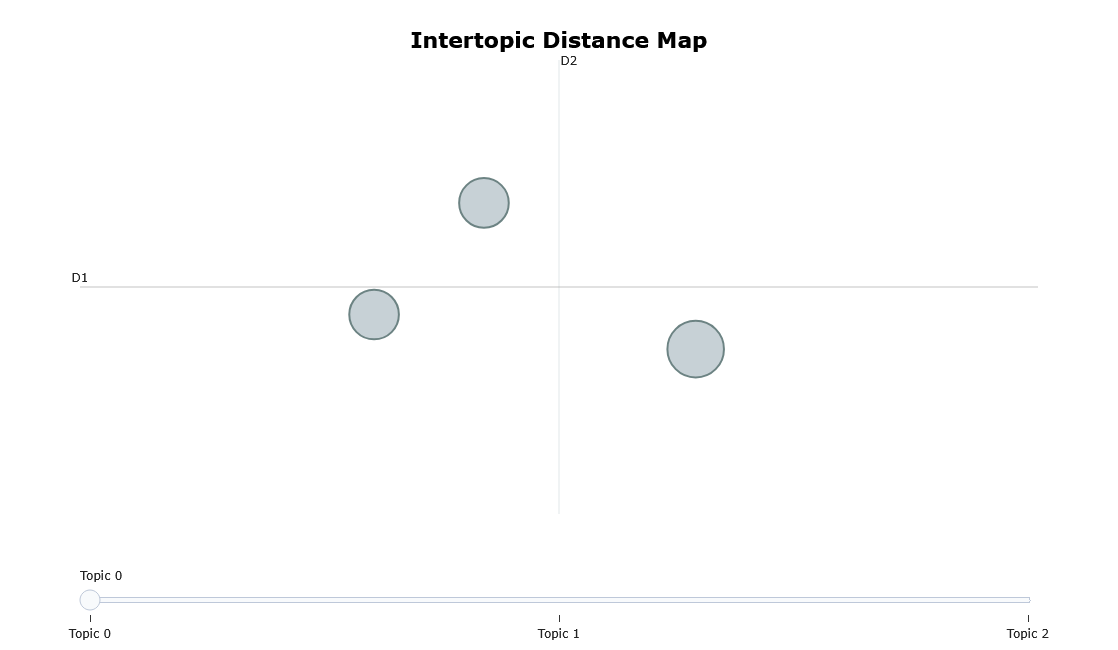

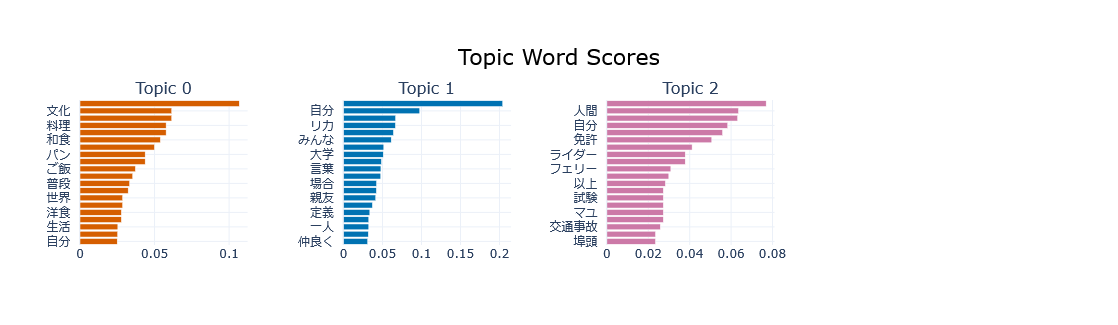

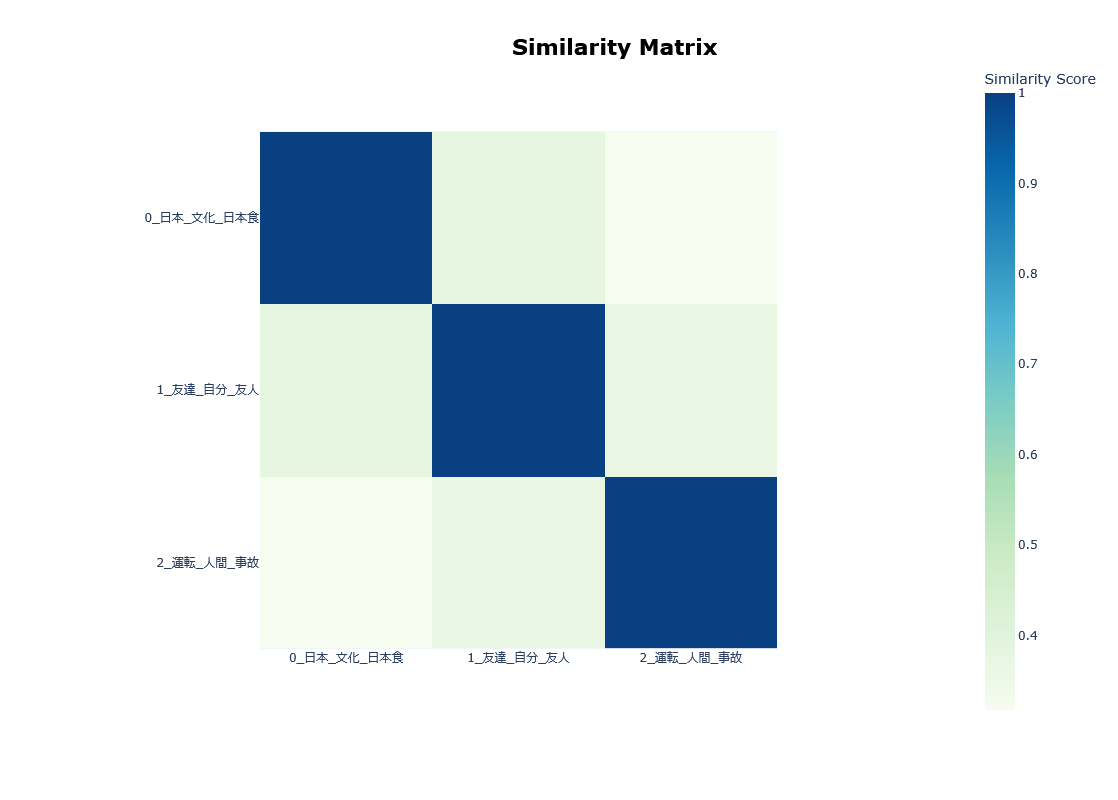

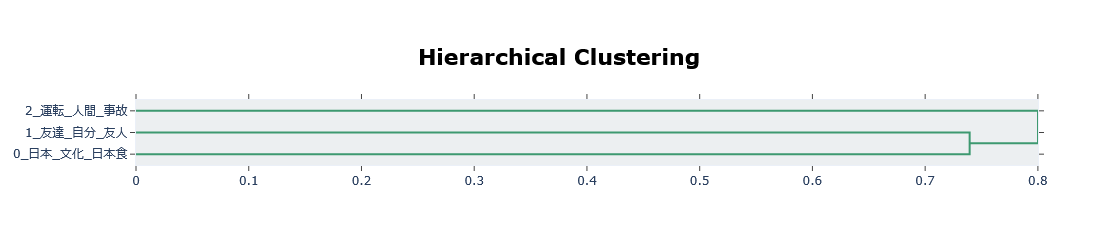

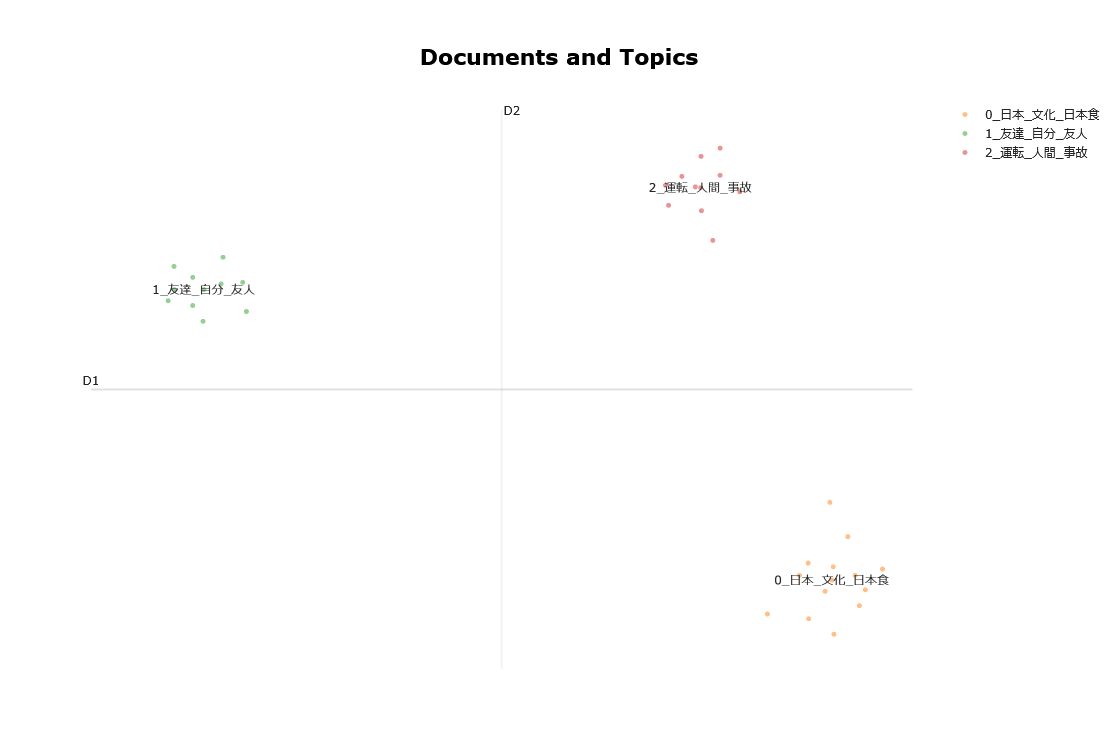

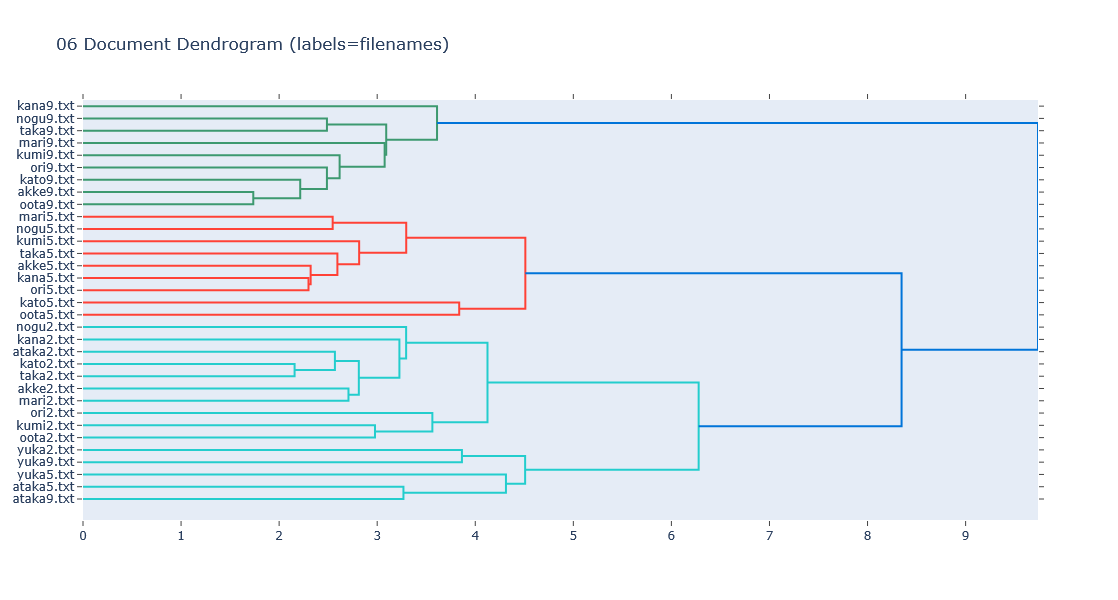

In [4]:
# ============================================================
# BERTopic 可視化・保存（CSV/HTML）＋ 文書樹形図（HTML）＋ Notebook display
# ============================================================
# 前提：このセルの前に以下が存在していること
#   - topic_model      : 学習済みBERTopicモデル
#   - topics           : 各文書のトピック割当（list[int]）
#   - filtered_raw     : 文書（生文）list[str]  ※表示や保存用
#   - filtered_docs    : 内容語トークン列 list[str]  ※fit_transformに渡した文書
#   - filtered_paths   : 文書ラベル（GitHub上のパス等）list[str]
#   - embedding_model  : SentenceTransformer（前セルで作成済み）  ★重要
#
# 必要（未インストールなら）:
#   pip install -U scipy plotly nbformat ipython
# ============================================================

import pandas as pd
from pathlib import Path
import numpy as np

# 樹形図（dendrogram）用
import plotly.figure_factory as ff
from scipy.cluster.hierarchy import linkage

# Notebook display
from IPython.display import display

# ============================================================
# 出力先
# ============================================================
out_dir = Path(".")
out_dir.mkdir(exist_ok=True)

# ============================================================
# 0) top_n_words=20 を反映（可能なら update_topics）
#   - 注意：今回のモデルは「c-TF-IDF用文書=filtered_docs（内容語列）」で学習しているので
#           update_topics に渡すのも filtered_docs が基本的に安全です。
# ============================================================
TARGET_TOP_N_WORDS = 20

updated = False
try:
    # update_topics を内容語列に対して実行（トピック語抽出側に合わせる）
    topic_model.update_topics(filtered_docs, top_n_words=TARGET_TOP_N_WORDS)
    updated = True
    print(f"[OK] update_topics で top_n_words={TARGET_TOP_N_WORDS} を反映しました")
except Exception as e:
    # update_topics が使えない/失敗する場合は諦めて、現状の top_n_words のまま可視化へ進む
    print("[WARN] update_topics に失敗しました。現状の設定のまま可視化します。")
    print("  reason:", repr(e))

# ============================================================
# 1) topic_info / docs_with_topics を保存（CSV）
#   - 保存する text は「生文（filtered_raw）」が分かりやすい
#   - content_words は「内容語列（filtered_docs）」も残しておくと後で便利
# ============================================================
topic_info = topic_model.get_topic_info()
topic_info.to_csv(out_dir / "topic_info.csv", index=False, encoding="utf-8-sig")

df_docs = pd.DataFrame({
    "path": filtered_paths,
    "topic": topics,
    "text": filtered_raw,
    "content_words": filtered_docs
})
df_docs.to_csv(out_dir / "docs_with_topics.csv", index=False, encoding="utf-8-sig")

print("[Saved] topic_info.csv, docs_with_topics.csv")

# ============================================================
# 2) 図示（HTML保存）
# ============================================================
topic_model.visualize_topics().write_html(out_dir / "01_topics.html")
topic_model.visualize_barchart(top_n_topics=30, n_words=TARGET_TOP_N_WORDS).write_html(out_dir / "02_barchart.html")
topic_model.visualize_heatmap().write_html(out_dir / "03_heatmap.html")
topic_model.visualize_hierarchy().write_html(out_dir / "04_hierarchy.html")

# visualize_documents は “表示する文書” を渡すので、生文（filtered_raw）が自然
topic_model.visualize_documents(filtered_raw, sample=min(1000, len(filtered_raw))).write_html(out_dir / "05_documents.html")

print("[Saved] 01_topics.html, 02_barchart.html, 03_heatmap.html, 04_hierarchy.html, 05_documents.html")

# ============================================================
# 3) 追加：ドキュメントの樹形図（ラベル=paths）→ HTML保存
#   - embedding_model は SentenceTransformer を明示使用（topic_model.embedding_model に依存しない）
# ============================================================
labels = [str(p).split("/")[-1].split("\\")[-1] for p in filtered_paths]

# 文書 embedding（生文から作るのが自然）
embeddings = np.array(embedding_model.encode(filtered_raw, show_progress_bar=True))

# 階層クラスタ（Ward法）
Z = linkage(embeddings, method="ward")

fig_dendro = ff.create_dendrogram(
    embeddings,
    linkagefun=lambda x: Z,
    labels=labels,
    orientation="left"
)

fig_dendro.update_layout(
    width=900,
    height=max(600, 18 * len(labels)),
    title="06 Document Dendrogram (labels=filenames)"
)

fig_dendro.write_html(out_dir / "06_document_dendrogram.html")
print("[Saved] 06_document_dendrogram.html")

print("\nAll saved outputs:")
print(" - topic_info.csv")
print(" - docs_with_topics.csv")
print(" - 01_topics.html")
print(f" - 02_barchart.html (n_words={TARGET_TOP_N_WORDS})")
print(" - 03_heatmap.html")
print(" - 04_hierarchy.html")
print(" - 05_documents.html")
print(" - 06_document_dendrogram.html")

# ============================================================
# 4) Notebook内で display（任意）
# ============================================================
display(topic_model.visualize_topics())
display(topic_model.visualize_barchart(top_n_topics=30, n_words=TARGET_TOP_N_WORDS))
display(topic_model.visualize_heatmap())
display(topic_model.visualize_hierarchy())
display(topic_model.visualize_documents(filtered_raw, sample=min(1000, len(filtered_raw))))
display(fig_dendro)


n_docs = 33
n_labels = 33
n_assigned_topics = 33
topic_ids_used (no -1): [0, 1, 2]
topic_ids_for_wordmap: [0, 1, 2]


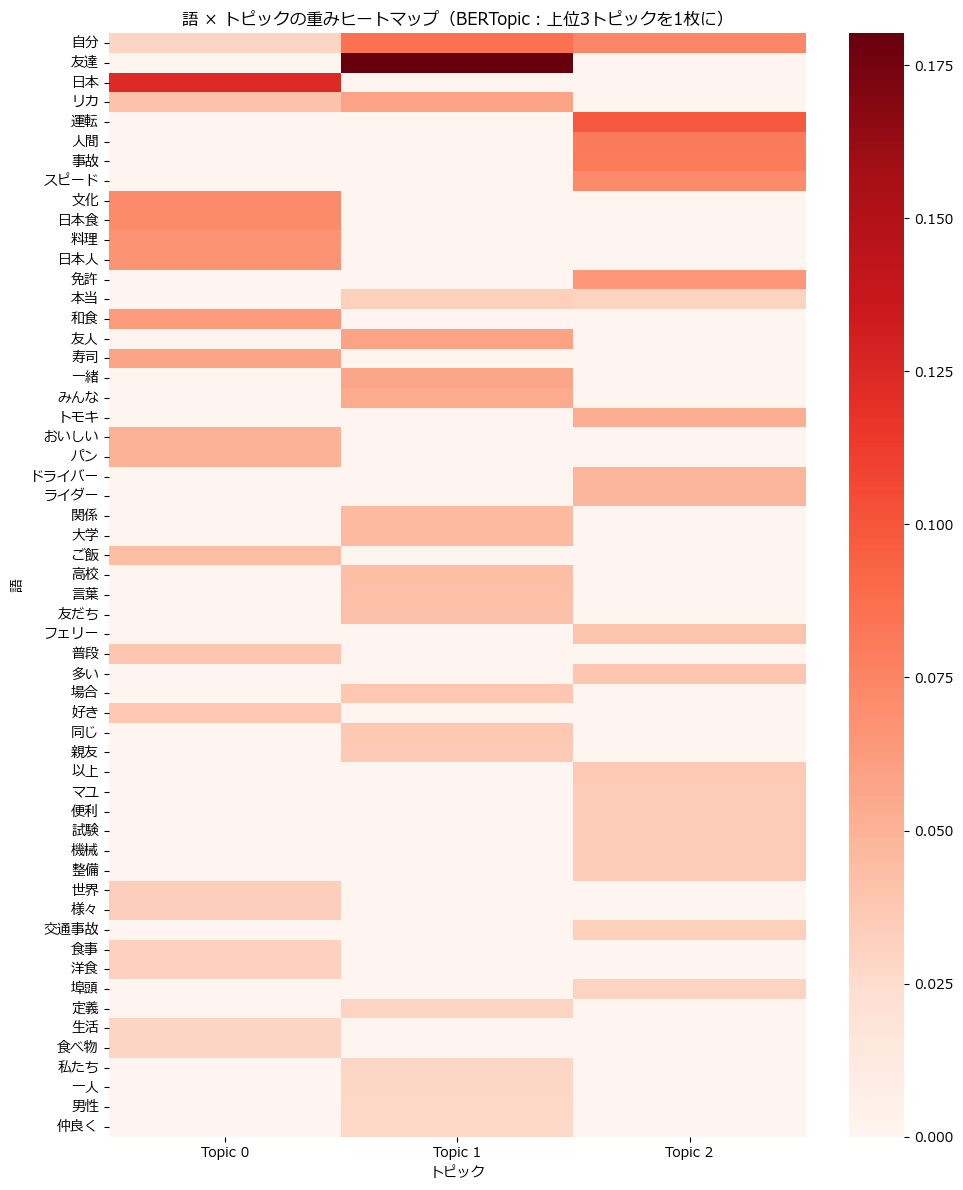

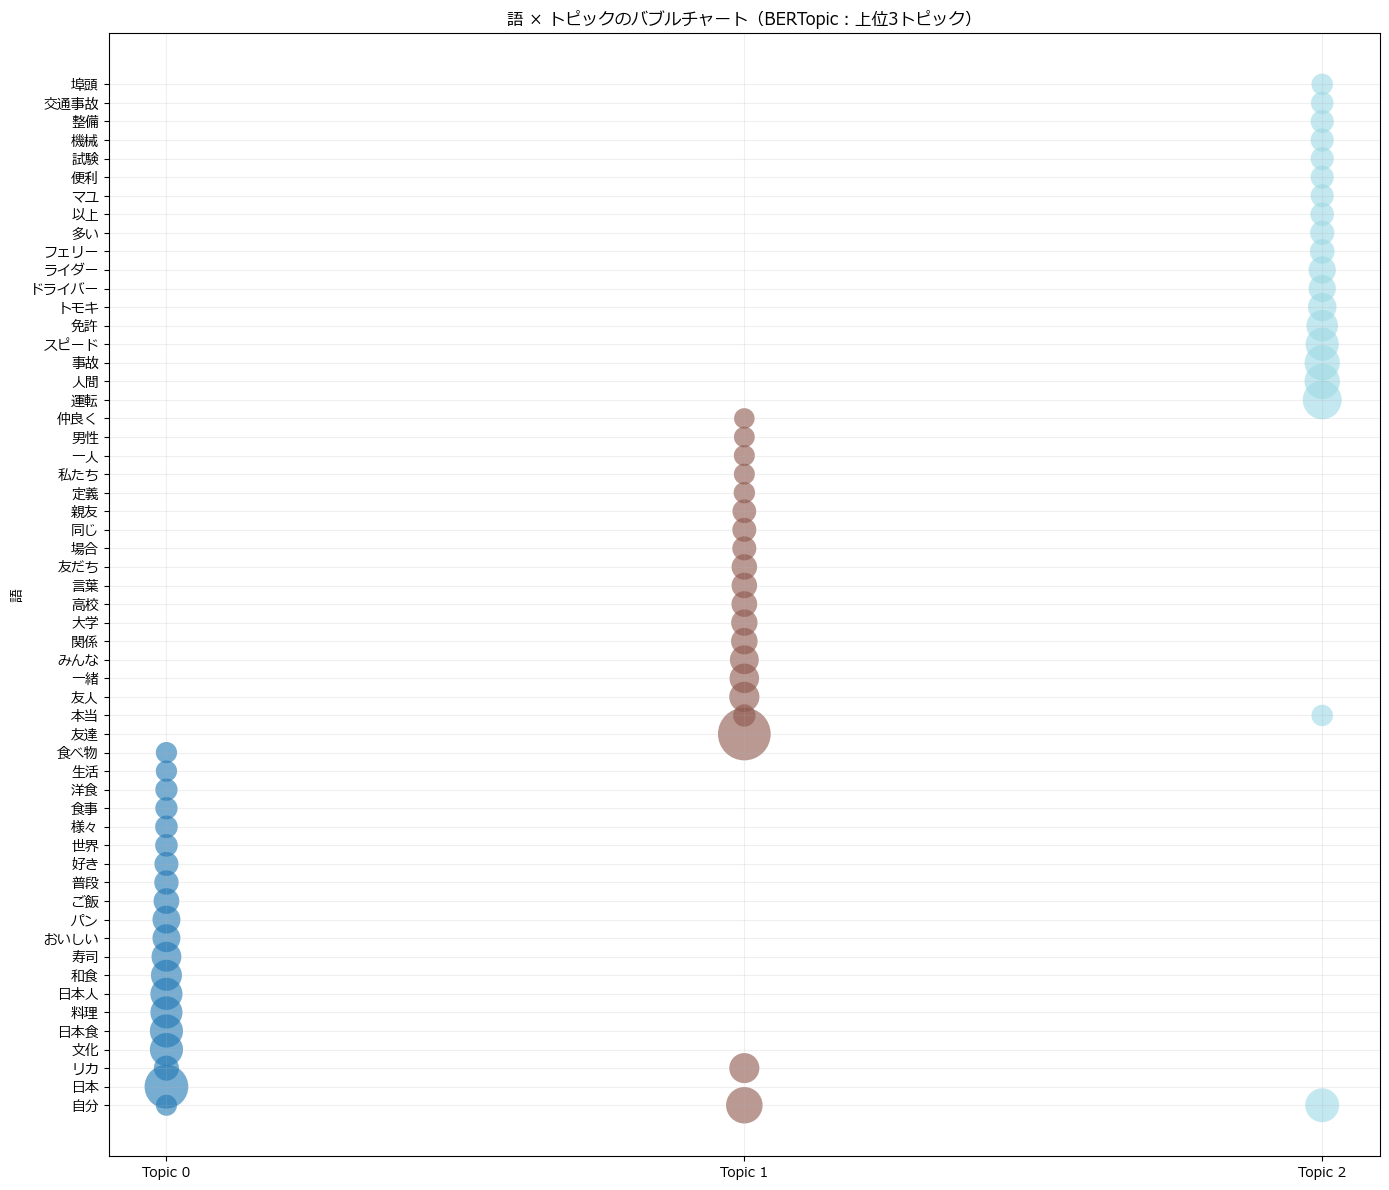

[INFO] doc×topic using 0/1 assignment: (33, 3)
doc_topic_df shape after cleaning: (33, 3)


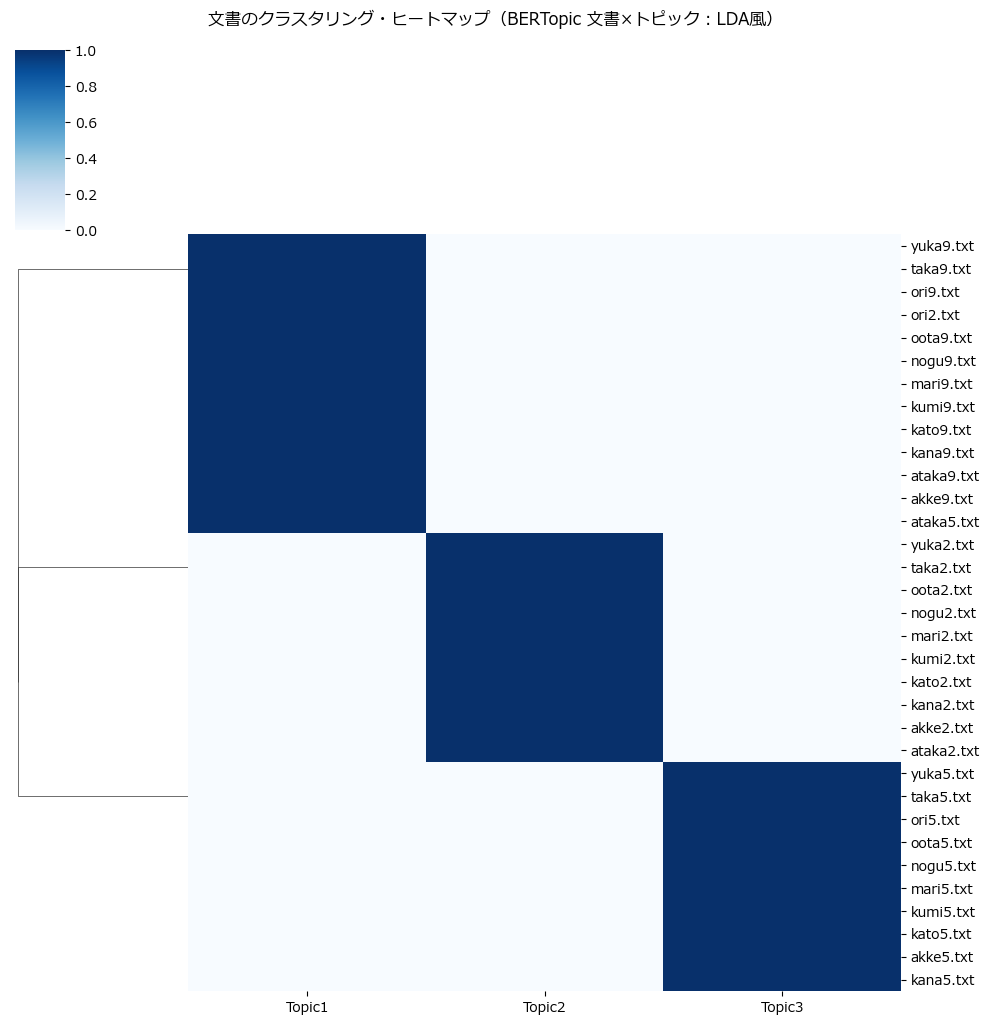

In [5]:
# 図示バージョン２
# ============================================================
# BERTopic版（統合・安定版）：
# ① 語×トピック ヒートマップ（3トピックを1枚にまとめる）
# ② 語×トピック バブルチャート（同じ3トピック）
# ③ 文書×トピック クラスタリング・ヒートマップ（LDA風：0/1所属 or probs）
#
# ✅ 互換性/安定性
# - 日本語フォント：Windows標準（無ければ既定へ）
# - matplotlib colormap：plt.get_cmap（古い/新しい両対応）
# - BERTopicの確率(probs)が環境で揺れても、③は0/1所属で確実に作れる
#
# ✅ 前提（このセルの前に存在）
#   topic_model : 学習済みBERTopic
#   filtered_raw: 文書 list[str]
#   filtered_paths: 文書ラベル list[str]
#   topics, probs: topic_model.fit_transform(...) の返り値（probsは無くてもOK）
# ============================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------
# 日本語フォント（Windows標準）
# ------------------------------
plt.rcParams["font.family"] = ["Meiryo", "Yu Gothic", "MS Gothic", "sans-serif"]

# ------------------------------
# 設定
# ------------------------------
TOP_N_TOPICS = 3              # ★ 3トピックを1枚に加える
TOP_WORDS_PER_TOPIC = 20      # 各トピックから拾う語数
TOP_WORDS_GLOBAL = 60         # ①②の表示語数（全トピック横断で上位）
FIGSIZE_HEATMAP = (10, 12)
FIGSIZE_BUBBLE  = (14, 12)
FIGSIZE_CLUST   = (10, 10)

# ③：確率っぽい濃淡（probs）でやりたいなら True（列対応が揺れる環境では不安定）
USE_PROBS_FOR_DOC_TOPIC = False

# ============================================================
# 0) サニティチェック
# ============================================================
print("n_docs =", len(filtered_raw))
print("n_labels =", len(filtered_paths))
print("n_assigned_topics =", len(topics))
if len(filtered_raw) != len(topics):
    raise ValueError("filtered_raw と topics の長さが一致していません（別データで可視化している可能性があります）。")

# 文書ラベル
if len(filtered_paths) == len(filtered_raw):
    doc_labels = [str(p).split("/")[-1].split("\\")[-1] for p in filtered_paths]
else:
    print("[WARN] filtered_paths の長さが filtered_raw と一致していません。doc_0.. を使用します。")
    doc_labels = [f"doc_{i}" for i in range(len(filtered_raw))]

# このデータで実際に出現したトピック（-1除外）
topic_ids_used = sorted({int(t) for t in topics if int(t) != -1})
print("topic_ids_used (no -1):", topic_ids_used)

# ============================================================
# 1) ①② 用：上位3トピックを選ぶ（-1除外、サイズ上位）
# ============================================================
topic_info = topic_model.get_topic_info()
topic_ids_for_wordmap = topic_info[topic_info["Topic"] != -1]["Topic"].head(TOP_N_TOPICS).tolist()
topic_ids_for_wordmap = [int(t) for t in topic_ids_for_wordmap]

print("topic_ids_for_wordmap:", topic_ids_for_wordmap)
if len(topic_ids_for_wordmap) < TOP_N_TOPICS:
    print(f"[WARN] トピックが {len(topic_ids_for_wordmap)} 個しかありません。存在する分だけ表示します。")

# ============================================================
# 2) 語×トピック行列（3トピックを1枚に）
# ============================================================
topic_words = {}
all_words = set()

for tid in topic_ids_for_wordmap:
    pairs = topic_model.get_topic(tid)
    if not pairs:
        continue
    pairs = pairs[:TOP_WORDS_PER_TOPIC]
    topic_words[tid] = pairs
    for w, _ in pairs:
        all_words.add(w)

all_words = sorted(all_words)

topic_word_df = pd.DataFrame(
    0.0,
    index=all_words,
    columns=[f"Topic {t}" for t in topic_ids_for_wordmap]
)

for tid in topic_ids_for_wordmap:
    col = f"Topic {tid}"
    for w, s in topic_words.get(tid, []):
        topic_word_df.loc[w, col] = float(s)

# トピック内正規化（列和=1）→ “確率っぽい”表示
topic_word_prob = topic_word_df.div(
    topic_word_df.sum(axis=0).replace(0, np.nan),
    axis=1
).fillna(0.0)

# 見やすさのため、全トピック横断で上位語だけ表示
top_words = (
    topic_word_prob.sum(axis=1)
    .sort_values(ascending=False)
    .head(TOP_WORDS_GLOBAL)
    .index
)
topic_word_prob_small = topic_word_prob.loc[top_words]

# ============================================================
# ① 語×トピック ヒートマップ（3トピックを1枚に）
# ============================================================
plt.figure(figsize=FIGSIZE_HEATMAP)
sns.heatmap(topic_word_prob_small, cmap="Reds")
plt.title("語 × トピックの重みヒートマップ（BERTopic：上位3トピックを1枚に）")
plt.xlabel("トピック")
plt.ylabel("語")
plt.tight_layout()
plt.show()

# ============================================================
# ② 語×トピック バブルチャート（同じ3トピック）
# ============================================================
bubble_df = topic_word_prob_small.reset_index().melt(
    id_vars="index",
    var_name="Topic",
    value_name="Prob"
)
bubble_df.columns = ["Word", "Topic", "Prob"]
bubble_df = bubble_df[bubble_df["Prob"] > 0]

topics_cols = list(topic_word_prob_small.columns)
cmap = plt.get_cmap("tab20")
topic_color_map = {t: cmap(i / max(1, len(topics_cols) - 1)) for i, t in enumerate(topics_cols)}

plt.figure(figsize=FIGSIZE_BUBBLE)
for t in topics_cols:
    sub = bubble_df[bubble_df["Topic"] == t]
    plt.scatter(
        x=[t] * len(sub),
        y=sub["Word"],
        s=sub["Prob"] * 8000,   # サイズ係数（必要なら調整）
        alpha=0.6,
        color=topic_color_map[t],
        edgecolors="none"
    )

plt.ylabel("語")
plt.title("語 × トピックのバブルチャート（BERTopic：上位3トピック）")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# ============================================================
# ③ 文書×トピック クラスタリング・ヒートマップ（LDA風）
#   - まずは “このデータで出現したトピックだけ” を列にして 0/1 で作る（確実に列数が合う）
#   - probsを使いたい場合は USE_PROBS_FOR_DOC_TOPIC=True（環境次第で列対応が揺れます）
# ============================================================

doc_topic_df = None

if USE_PROBS_FOR_DOC_TOPIC:
    try:
        P = np.asarray(probs)
        if P.ndim == 2 and P.shape[0] == len(filtered_raw):
            P = np.nan_to_num(P.astype(float), nan=0.0, posinf=0.0, neginf=0.0)
            doc_topic_df = pd.DataFrame(
                P,
                index=doc_labels,
                columns=[f"Topic{j+1}" for j in range(P.shape[1])]
            )
            print("[INFO] doc×topic using probs:", doc_topic_df.shape)
        else:
            print("[WARN] probs が2次元ではない/文書数が合わないため 0/1 所属にフォールバックします。")
    except Exception:
        print("[WARN] probs を使えないため 0/1 所属にフォールバックします。")

if doc_topic_df is None:
    if len(topic_ids_used) == 0:
        raise RuntimeError("有効なトピックがありません（全て -1 の可能性）。min_cluster_size などを調整してください。")

    doc_topic = np.zeros((len(topics), len(topic_ids_used)), dtype=float)
    topic_to_col = {tid: j for j, tid in enumerate(topic_ids_used)}

    for i, t in enumerate(topics):
        t = int(t)
        if t == -1:
            continue
        doc_topic[i, topic_to_col[t]] = 1.0

    doc_topic_df = pd.DataFrame(
        doc_topic,
        index=doc_labels,
        columns=[f"Topic{j+1}" for j in range(len(topic_ids_used))]
    )
    print("[INFO] doc×topic using 0/1 assignment:", doc_topic_df.shape)

# NaN/inf/全ゼロ行/列を除去（クラスタ計算を安定化）
doc_topic_df = doc_topic_df.replace([np.inf, -np.inf], 0.0).fillna(0.0)

row_norm = np.linalg.norm(doc_topic_df.values, axis=1)
doc_topic_df = doc_topic_df.loc[row_norm > 0]

col_norm = np.linalg.norm(doc_topic_df.values, axis=0)
doc_topic_df = doc_topic_df.loc[:, col_norm > 0]

print("doc_topic_df shape after cleaning:", doc_topic_df.shape)

if doc_topic_df.shape[0] < 2:
    raise RuntimeError("有効な文書が2未満でクラスタリングできません。")

# LDA例に合わせて：列はクラスタしない（必要なら True）
col_cluster = False

# 0/1はeuclideanが素直、probsはcosineでも良いが落ちたらeuclideanへ
metric = "cosine" if USE_PROBS_FOR_DOC_TOPIC else "euclidean"
method = "average"

try:
    g = sns.clustermap(
        doc_topic_df,
        method=method,
        metric=metric,
        cmap="Blues",
        figsize=FIGSIZE_CLUST,
        row_cluster=True,
        col_cluster=col_cluster
    )
except ValueError:
    print("[WARN] clustermap failed; fallback metric=euclidean")
    g = sns.clustermap(
        doc_topic_df,
        method=method,
        metric="euclidean",
        cmap="Blues",
        figsize=FIGSIZE_CLUST,
        row_cluster=True,
        col_cluster=col_cluster
    )

plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=0)
plt.suptitle("文書のクラスタリング・ヒートマップ（BERTopic 文書×トピック：LDA風）", y=1.02)
plt.show()


In [31]:
import os
import glob
import pandas as pd

from bertopic import BERTopic
import umap
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer

# ============================================================
# 設定（ローカルフォルダ版）
# ============================================================
LOCAL_FOLDER = r"F:\livedore"
TEXT_EXT = ".txt"
MIN_CHARS = 20

OUT_DOCS_CSV = "docs_with_topics.csv"
OUT_TOPICINFO_CSV = "topic_info.csv"
OUT_TOPICS_HTML = "bertopic_topics.html"

# ============================================================
# ローカルフォルダ内の txt ファイル一覧を取得
# ============================================================
files = sorted(glob.glob(os.path.join(LOCAL_FOLDER, f"*{TEXT_EXT}")))
print(f"Found txt files: {len(files)}")

if len(files) == 0:
    raise RuntimeError("このフォルダに .txt が見つかりませんでした。")

# ============================================================
# テキスト読み込み
# ============================================================
docs = []
paths = []

for file in files:
    try:
        with open(file, "r", encoding="utf-8") as f:
            text = f.read().strip()
    except UnicodeDecodeError:
        with open(file, "r", encoding="shift_jis", errors="ignore") as f:
            text = f.read().strip()

    if len(text) >= MIN_CHARS:
        docs.append(text)
        paths.append(file)

print(f"Valid documents: {len(docs)}")

# ============================================================
# Sentence-BERT による埋め込みモデル
# ============================================================
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# ============================================================
# UMAP（視覚的な分離を強化）
# ============================================================
umap_model = umap.UMAP(
    n_neighbors=15,      # ← 安定性と分離のバランス
    n_components=5,      # ← クラスタ構造を豊かにする
    min_dist=0.0,        # ← トピックの分離を強調
    metric="cosine"
)

# ============================================================
# HDBSCAN（トピック数を抑える）
# ============================================================
hdbscan_model = HDBSCAN(
    min_cluster_size=30,   # ← 小さなトピックを抑制
    min_samples=10,        # ← 密度の要求を強める
    prediction_data=True
)

# ============================================================
# BERTopic モデルの作成
# ============================================================
topic_model = BERTopic(
    embedding_model=embedding_model,
    language="multilingual",
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    top_n_words=10,
    verbose=True
)

# ============================================================
# トピックモデルの学習
# ============================================================
topics, probs = topic_model.fit_transform(docs)

# ============================================================
# ★ トピック数を10に固定（後処理）
# ============================================================
topic_model = topic_model.reduce_topics(docs, nr_topics=10)

# ============================================================
# 結果の保存
# ============================================================
df = pd.DataFrame({
    "path": paths,
    "topic": topics,
    "text": docs
})
df.to_csv(OUT_DOCS_CSV, index=False, encoding="utf-8-sig")

topic_info = topic_model.get_topic_info()
topic_info.to_csv(OUT_TOPICINFO_CSV, index=False, encoding="utf-8-sig")

fig = topic_model.visualize_topics()
fig.write_html(OUT_TOPICS_HTML)

print("Saved:")
print(" -", OUT_DOCS_CSV)
print(" -", OUT_TOPICINFO_CSV)
print(" -", OUT_TOPICS_HTML)

Found txt files: 2605
Valid documents: 2605


2026-01-24 10:28:01,024 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/82 [00:00<?, ?it/s]

2026-01-24 10:29:46,807 - BERTopic - Embedding - Completed ✓
2026-01-24 10:29:46,807 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-24 10:29:55,956 - BERTopic - Dimensionality - Completed ✓
2026-01-24 10:29:55,956 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-24 10:29:56,030 - BERTopic - Cluster - Completed ✓
2026-01-24 10:29:56,034 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-24 10:29:56,937 - BERTopic - Representation - Completed ✓
2026-01-24 10:29:57,221 - BERTopic - Topic reduction - Reducing number of topics
2026-01-24 10:29:57,246 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-24 10:29:58,103 - BERTopic - Representation - Completed ✓
2026-01-24 10:29:58,103 - BERTopic - Topic reduction - Reduced number of topics from 16 to 10


Saved:
 - docs_with_topics.csv
 - topic_info.csv
 - bertopic_topics.html
